In [2]:
import glob
import pandas as pd
import numpy as np
from autogluon.tabular import TabularPredictor
import seaborn as sns

np.random.seed(29)

In [3]:
# 'genuine_test\\authentication_attempts_2.csv'

genuine_train_string = 'genuine_train\\authentication_attempts'
genuine_test_string = 'genuine_test\\authentication_attempts'

impersonator_train_string = 'impersonator_train\\authentication_attempts'
impersonator_test_string = 'impersonator_test\\authentication_attempts'


In [9]:
all_results = pd.DataFrame(columns=['traces_provided', 'accuracy', 'balanced_accuracy', 'mcc'])

max_traces = 10

for num_traces in range(2, max_traces+1, 1):
    print('---------------')
    print(num_traces)
    print('---------------')

    # Gather training data of matching number of traces
    genuine_train_df = pd.read_csv(f'{genuine_train_string}_{num_traces}.csv', index_col=[0])
    impersonator_train_df = pd.read_csv(f'{impersonator_train_string}_{num_traces}.csv', index_col=[0])

    combined_training_df = pd.concat([genuine_train_df, impersonator_train_df])

    # Train an authenticator based on the number of traces
    # The validatation set used during trainind is really small, so accuracy look bad while training
    authenticator = TabularPredictor(label='label', eval_metric='balanced_accuracy').fit(combined_training_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)

    # Create test df for the correct number of traces
    genuine_test_df = pd.read_csv(f'{genuine_test_string}_{num_traces}.csv', index_col=[0])
    impersonator_test_df = pd.read_csv(f'{impersonator_test_string}_{num_traces}.csv', index_col=[0])

    combined_testing_df = pd.concat([genuine_test_df, impersonator_test_df])

    y_pred = authenticator.predict(combined_testing_df)
    results = authenticator.evaluate(combined_testing_df)



    new_results = {'traces_provided':num_traces, 'accuracy':results['accuracy'], 'balanced_accuracy':results['balanced_accuracy'], 'mcc':results['mcc']}
    all_results.loc[len(all_results)] = (new_results)

No path specified. Models will be saved in: "AutogluonModels\ag-20250404_020402"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.43 GB / 63.72 GB (79.2%)
Disk Space Avail:   889.86 GB / 1906.98 GB (46.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\AutogluonModels\ag-20250404_020402"
Train Data Rows:    11234
Train Data Columns: 2
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may spe

---------------
2
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.5	 = Validation score   (balanced_accuracy)
	0.59s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.5	 = Validation score   (balanced_accuracy)
	0.65s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.5	 = Validation score   (balanced_accuracy)
	0.39s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.5	 = Validation score   (balanced_accuracy)
	0.38s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not

---------------
3
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.5	 = Validation score   (balanced_accuracy)
	0.75s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.5	 = Validation score   (balanced_accuracy)
	0.89s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.5	 = Validation score   (balanced_accuracy)
	0.39s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.5	 = Validation score   (balanced_accuracy)
	0.35s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If it is not

...

Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.514	 = Validation score   (balanced_accuracy)
	0.8s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.509	 = Validation score   (balanced_accuracy)
	1.35s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.5027	 = Validation score   (balanced_accuracy)
	0.35s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.5027	 = Validation score   (balanced_accuracy)
	0.34s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. If 

---------------
9
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.8066	 = Validation score   (balanced_accuracy)
	0.88s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.5103	 = Validation score   (balanced_accuracy)
	1.35s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.5078	 = Validation score   (balanced_accuracy)
	0.36s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.5078	 = Validation score   (balanced_accuracy)
	0.31s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. 

---------------
10
---------------


Fitting model: KNeighborsDist ...
	No valid features to train KNeighborsDist... Skipping this model.
Fitting model: LightGBMXT ...
	Training LightGBMXT with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7819	 = Validation score   (balanced_accuracy)
	0.83s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ...
	Training LightGBM with GPU, note that this may negatively impact model quality compared to CPU training.
	0.7903	 = Validation score   (balanced_accuracy)
	1.09s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: RandomForestGini ...
	0.7904	 = Validation score   (balanced_accuracy)
	0.35s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestEntr ...
	0.7904	 = Validation score   (balanced_accuracy)
	0.31s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: CatBoost ...
		Import catboost failed. Numpy version may be outdated, Please ensure numpy version >=1.17.0. 

In [12]:
all_results

,traces_provided,accuracy,balanced_accuracy,mcc
0,2,0.968951,0.965445,0.906193
1,3,0.989554,0.984368,0.967271
2,4,0.991421,0.982489,0.972952
3,5,0.987911,0.969388,0.961689
4,6,0.997581,0.995432,0.992385
5,7,0.996234,0.994064,0.988129
6,8,0.998922,0.997268,0.996595
7,9,0.995128,0.987578,0.984521
8,10,0.998647,0.999161,0.995685


# Optimal authentications traces == 6

<Axes: xlabel='traces_provided', ylabel='value'>

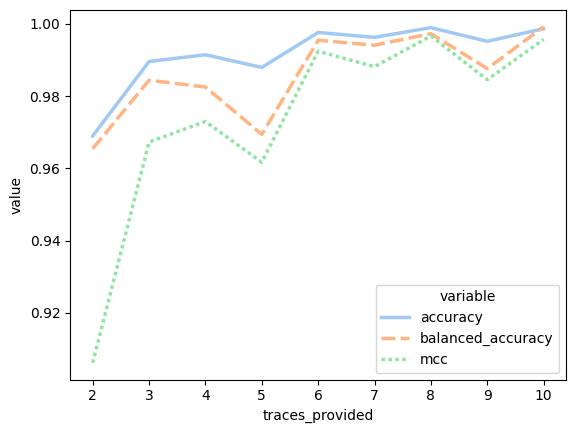

In [13]:
sns.lineplot(data=pd.melt(all_results, ['traces_provided']), x='traces_provided', y='value', style="variable", hue='variable', palette="pastel", linewidth=2.5)

# Train and export a model using the optimal 6 traces

In [16]:
# Gather training data of matching number of traces
num_traces = 6

genuine_train_df = pd.read_csv(f'{genuine_train_string}_{num_traces}.csv', index_col=[0])
impersonator_train_df = pd.read_csv(f'{impersonator_train_string}_{num_traces}.csv', index_col=[0])

combined_training_df = pd.concat([genuine_train_df, impersonator_train_df])

# Train an authenticator based on the number of traces
# The validatation set used during trainind is really small, so accuracy look bad while training
authenticator = TabularPredictor(label='label', eval_metric='mcc').fit(combined_training_df, num_gpus=1, presets='medium_quality', fit_weighted_ensemble=False)

# Create test df for the correct number of traces
genuine_test_df = pd.read_csv(f'{genuine_test_string}_{num_traces}.csv', index_col=[0])
impersonator_test_df = pd.read_csv(f'{impersonator_test_string}_{num_traces}.csv', index_col=[0])

combined_testing_df = pd.concat([genuine_test_df, impersonator_test_df])

y_pred = authenticator.predict(combined_testing_df)
results = authenticator.evaluate(combined_testing_df)

No path specified. Models will be saved in: "AutogluonModels\ag-20250404_020752"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          32
Memory Avail:       50.41 GB / 63.72 GB (79.1%)
Disk Space Avail:   889.79 GB / 1906.98 GB (46.7%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ...
AutoGluon will save models to "c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\AutogluonModels\ag-20250404_020752"
Train Data Rows:    3739
Train Data Columns: 6
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  ['genuine', 'impersonator']
	If 'binary' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may spec

In [19]:
authenticator.leaderboard(combined_testing_df)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.992385,0.551526,mcc,0.010506,0.000000,2.921228,0.010506,0.000000,2.921228,1,True,9
1,LightGBMXT,0.979642,0.484883,mcc,0.014156,0.008678,1.305293,0.014156,0.008678,1.305293,1,True,1
2,XGBoost,0.977103,0.479843,mcc,0.037286,0.006182,1.033274,0.037286,0.006182,1.033274,1,True,8
3,LightGBMLarge,0.971964,0.484883,mcc,0.009771,0.009306,2.187899,0.009771,0.009306,2.187899,1,True,10
4,NeuralNetFastAI,0.968186,0.100578,mcc,0.020188,0.000000,1.799140,0.020188,0.000000,1.799140,1,True,7
5,ExtraTreesEntr,0.958835,0.464782,mcc,0.042268,0.032902,0.318516,0.042268,0.032902,0.318516,1,True,6
6,ExtraTreesGini,0.958835,0.464782,mcc,0.042923,0.032168,0.333881,0.042923,0.032168,0.333881,1,True,5
7,LightGBM,0.957724,0.482564,mcc,0.009022,0.013208,1.098225,0.009022,0.013208,1.098225,1,True,2
8,RandomForestEntr,0.956201,0.469793,mcc,0.056806,0.032450,0.333411,0.056806,0.032450,0.333411,1,True,4
9,RandomForestGini,0.956201,0.464782,mcc,0.068438,0.043988,0.373667,0.068438,0.043988,0.373667,1,True,3


In [17]:
results

{'mcc': np.float64(0.9923849323263946),
 'accuracy': 0.9975806451612903,
 'balanced_accuracy': np.float64(0.9954319412409416),
 'roc_auc': np.float64(0.9999038949142006),
 'f1': np.float64(0.9984917043740573),
 'precision': np.float64(0.9979899497487437),
 'recall': np.float64(0.9989939637826962)}

In [20]:
# will return the path to the cloned predictor, identical to save_path_clone_opt
path_clone_opt = authenticator.clone_for_deployment(path='authenticator')

Cloned TabularPredictor located in 'c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\AutogluonModels\ag-20250404_020752' to 'authenticator'.
	To load the cloned predictor: predictor_clone = TabularPredictor.load(path="authenticator")
Clone: Keeping minimum set of models required to predict with best model 'NeuralNetTorch'...
Deleting model LightGBMXT. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\authenticator\models\LightGBMXT will be removed.
Deleting model LightGBM. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\authenticator\models\LightGBM will be removed.
Deleting model RandomForestGini. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\authenticator\models\RandomForestGini will be removed.
Deleting model RandomForestEntr. All files under c:\Users\zac\Documents\github\IoT-GPU-ID\Experiment 3 - Authentication Model\auth

In [21]:
predictor_clone_opt = TabularPredictor.load(path='authenticator')

In [22]:
predictor_clone_opt.leaderboard(combined_testing_df)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,0.992385,0.551526,mcc,0.016778,0.0,2.921228,0.016778,0.0,2.921228,1,True,1


In [23]:
size_original = authenticator.disk_usage()
size_opt = predictor_clone_opt.disk_usage()
print(f'Size Original:  {size_original} bytes')
print(f'Size Optimized: {size_opt} bytes')
print(f'Optimized predictor achieved a {round((1 - (size_opt/size_original)) * 100, 1)}% reduction in disk usage.')

Size Original:  8934203 bytes
Size Optimized: 245535 bytes
Optimized predictor achieved a 97.3% reduction in disk usage.
